# Lab3_2024

In [1]:
import random
import hashlib
def generate_data_points(school_number):
    x_coordinates = list(range(8))
    school_number_str = str(school_number)
    hash_object = hashlib.sha256(school_number_str.encode('utf-8'))
    hash_value = int(hash_object.hexdigest(), 16)
    random.seed(hash_value)
    y_coordinates = [random.uniform(-5, 5) for _ in range(8)]
    return x_coordinates, y_coordinates

school_number = 23030320 # 请替换成你的学号
data_points = generate_data_points(school_number)

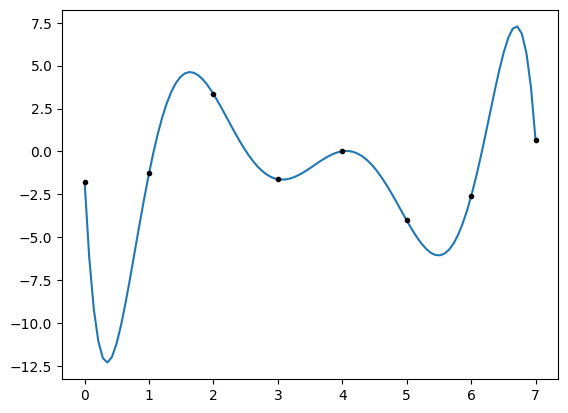

In [2]:
import operator
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt
def lagrange_basis(xs, i):
    '''
    在点 x_i 计算相应的 Lagrange 基
    '''
    n = len(xs)
    assert i in range(n), '所给下标超出范围'
    # 使⽤⾼阶函数
    def _basis(x):
        terms = [(x - xs[k]) / (xs[i] - xs[k]) for k in range(n) if k != i]
        return reduce(operator.mul, terms, 1)
    return _basis

def lagrange_interpolate(xs, ys):
    '''
    基函数的线性组合
    '''
    n = len(xs) 
    assert len(xs) == len(ys), '所给节点⻓度不匹配'
    # 使⽤⾼阶函数
    def _func(x):
        return sum(lagrange_basis(xs, i)(x) * ys[i] for i in range(n))
    return _func
# 示例插值节点
xvalues, yvalues = data_points
# 创建插值函数
ifunc = lagrange_interpolate(xvalues, yvalues)
xs = np.linspace(xvalues[0], xvalues[-1], 100)
ys = [ifunc(x) for x in xs]
plt.plot(xs, ys)
plt.plot(xvalues, yvalues, 'k.')
plt.show()

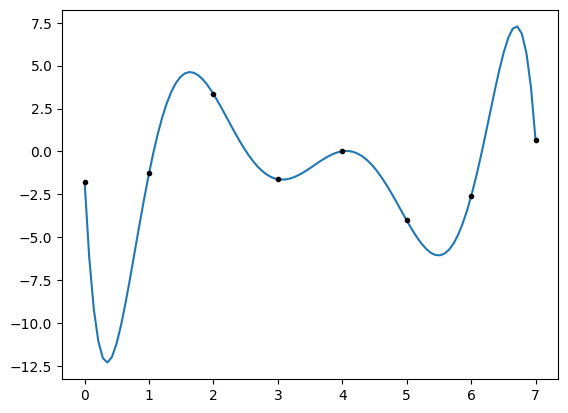

In [3]:
def newton_interpolate(xs, ys):
    '''
    ⽣成⼀个函数，⽤于计算基于给定数据点的⽜顿插值多项式的值。
    '''
    def _divided_difference(xs, ys):
        """
        计算差商表并返回差商系数。
        xs: 数据点的 x 坐标
        ys: 数据点的 y 坐标
        返回: 差商表的第一行系数
        """
        n = len(xs)
        coef = [y for y in ys]  # 初始化系数为 y 值

        # 计算差商表
        for i in range(1, n):
            for j in range(n - 1, i - 1, -1):
                coef[j] = (coef[j] - coef[j - 1]) / (xs[j] - xs[j - i])

        return coef  # 返回差商系数

    # 计算差商表并获取系数
    coef = _divided_difference(xs, ys)
    # 返回计算插值的函数
    def _interpolated_function(x):
        total = coef[0]
        product_term = 1
        for i in range(1, len(xs)):
            product_term *= (x - xs[i-1])
            total += coef[i] * product_term
        return total
    return _interpolated_function
# 示例插值节点
xvalues, yvalues = data_points
# 创建插值函数
ifunc = newton_interpolate(xvalues, yvalues)
xs = np.linspace(xvalues[0], xvalues[-1], 100)
ys = [ifunc(x) for x in xs]
plt.plot(xs, ys)
plt.plot(xvalues, yvalues, 'k.')
plt.show()

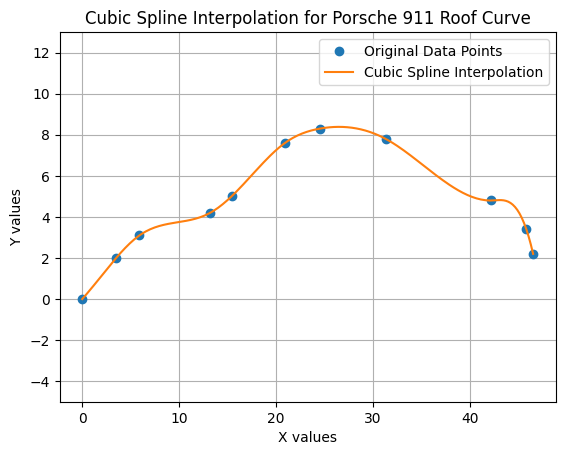

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 定义给定的数据点（保时捷 911 车顶曲线的示例数据）
data_points = [
    [0.0, 0.0],
    [3.5, 2.0],
    [5.9, 3.1],
    [13.2, 4.2],
    [15.4, 5.0],
    [20.9, 7.6],
    [24.5, 8.3],
    [31.3, 7.8],
    [42.2, 4.8],
    [45.8, 3.4],
    [46.5, 2.2]
]

# 分离 x 和 y 坐标
x_values, y_values = zip(*data_points)

# 创建三次样条插值函数
spline_func = interp1d(x_values, y_values, kind='cubic')

# 生成插值点
x_new = np.linspace(min(x_values), max(x_values), 200)
y_new = spline_func(x_new)

# 绘制图形
plt.plot(x_values, y_values, 'o', label='Original Data Points')  # 原始数据点
plt.plot(x_new, y_new, '-', label='Cubic Spline Interpolation')  # 三次样条插值曲线
plt.xlabel("X values")
plt.ylabel("Y values")
plt.ylim((-5, 13))
plt.title("Cubic Spline Interpolation for Porsche 911 Roof Curve")
plt.legend()
plt.grid()
plt.show()


给定的中国人口数据是：

| 年份（年） | 人口（亿） |
|------------|------------|
| 1953       | 5.82       |
| 1964       | 6.95       |
| 1982       | 10.08      |
| 1990       | 11.34      |
| 2000       | 12.66      |

In [5]:
import numpy as np

# 给定数据
years = np.array([1953, 1964, 1982, 1990, 2000])
population = np.array([5.82, 6.95, 10.08, 11.34, 12.66])

# 将年份数据平移
years_shifted = years - years[0]

# 对数变换，使用线性最小二乘法拟合 log(P) = log(a) + bt
log_population = np.log(population)

# 设计矩阵
X = np.vstack([np.ones(len(years_shifted)), years_shifted]).T

# 最小二乘法求解参数
coef = np.linalg.lstsq(X, log_population, rcond=None)[0]
log_a, b = coef
a = np.exp(log_a)

# 实现 afunc 函数
def afunc(year):
    """
    使用拟合的指数模型预测指定年份的人口
    """
    t = year - years[0]  # 将年份平移
    return a * np.exp(b * t)

In [6]:
# 测试 afunc 函数，预测 2010 年人口
predicted_population_2010 = afunc(2010)
print(f"2010年预测人口: {predicted_population_2010:.2f} 亿")

2010年预测人口: 15.65 亿


2010年预测人口: 15.65 亿


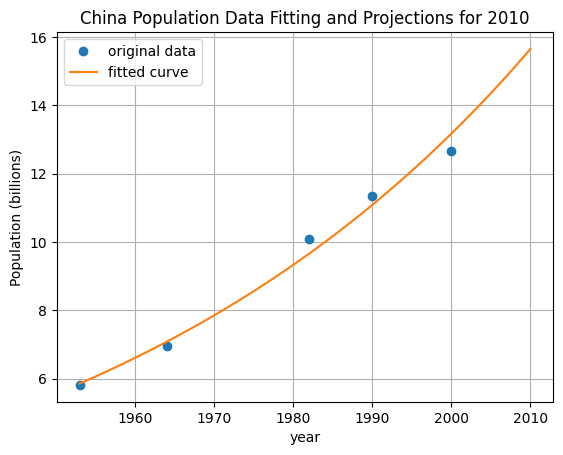

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 给定数据
years = np.array([1953, 1964, 1982, 1990, 2000])
population = np.array([5.82, 6.95, 10.08, 11.34, 12.66])

# 将年份数据平移
years_shifted = years - years[0]

# 对数变换，使用线性最小二乘法拟合 log(P) = log(a) + bt
log_population = np.log(population)

# 设计矩阵
X = np.vstack([np.ones(len(years_shifted)), years_shifted]).T

# 最小二乘法求解参数
coef = np.linalg.lstsq(X, log_population, rcond=None)[0]
log_a, b = coef
a = np.exp(log_a)

# 创建拟合函数
def population_model(year):
    t = year - years[0]  # 使用平移后的年份
    return a * np.exp(b * t)

# 预测2010年人口
predicted_population_2010 = population_model(2010)

# 输出预测结果
print(f"2010年预测人口: {predicted_population_2010:.2f} 亿")

# 绘制拟合曲线和原始数据
years_fit = np.linspace(1953, 2010, 100)
population_fit = population_model(years_fit)

plt.plot(years, population, 'o', label="original data")
plt.plot(years_fit, population_fit, '-', label="fitted curve")
plt.xlabel("year")
plt.ylabel("Population (billions)")
plt.title("China Population Data Fitting and Projections for 2010")
plt.legend()
plt.grid()
plt.show()
